<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch15_Working_with_Prediction_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 15 — Working with Outlier Detection Predictions

Getting a detector to produce scores is half the job. Once it runs in production — flagging dozens or hundreds of records a day against live data — the remaining work is **everything that happens downstream of the score**: investigating what each flag means, categorizing recurring outlier types, filtering known-and-understood cases, tracking drift over time, and improving the system as labeled data accumulates.

Most ML textbooks end where detection ends. That's a mistake: the operational workflow is where outlier-detection projects succeed or fail. A perfect detector that dumps 500 unlabeled scores per day onto an investigator's desk is worse than a 90%-accurate detector that sorts its flags into five clearly named categories with importance scores.

This chapter is about that operational layer — four disciplines that compound on each other:

1. **Hand-labeling** (§15.1) — attach categorical and importance labels to every flag you investigate. These labels are the raw material for everything else.
2. **Examining flagged outliers** (§15.2) — figure out *why* the detector flagged each record, using manual inspection, interpretable proxy detectors, and subspace analysis.
3. **Automating the sort** (§15.3) — build rules and one-class-per-category classifiers that route incoming flags into the known categories automatically.
4. **Semisupervised learning & regression testing** (§15.4–§15.5) — use accumulated labels to train stronger detectors (XGBOD-style stacking) and to build regression tests that catch quality drops when you retrain.

---

## Notebook roadmap

| Section | Topic |
|---|---|
| §15.1 | Hand-labeling: binary, category, importance |
| §15.2 | Examining outliers: manual inspection, ECOD/COD proxies, 2D subspaces |
| §15.3 | Automating sorting: rules (deterministic) + one-class-per-category classifiers |
| §15.4 | **Semisupervised learning** — stacked ensembles with labeled data, XGBOD |
| §15.5 | **Regression testing** — retraining without regressions |

> 📚 **Environment note.** The book uses the KDD Cup '99 SA dataset fetched from OpenML / scikit-learn's remote store. This sandbox has no internet, so we synthesize a KDD-SA-like dataset (8,000 rows × 41 features, 20% anomaly prevalence, four attack types: `neptune.`, `smurf.`, `portsweep.`, `guess_passwd.`) calibrated to produce detector behavior matching the book's figures. **Appendix A.1** has the drop-in cell for the real dataset on Colab.

---


## 15.1  Hand-labeling output

Every record an investigator touches should leave behind three pieces of metadata:

1. A **binary label** — is this a genuine outlier we want to flag in the future, or a statistically unusual record that isn't of interest?
2. A **category label** — which type of outlier is this? (fraud / error / misconfiguration / scan attempt / …) Categories matter more than binary labels because they drive grouping, filtering, and automated triage.
3. An **importance score** — how serious is this outlier? Low / medium / high, or a numeric 1–5. Detectors score *statistical unusualness*; humans score *business impact*. These are not the same thing.

The critical distinction the book makes: **a label of "investigated and found benign" is NOT the same as "we want the system to stop flagging records like this."** A large journal entry posted by a senior staff member may be investigated, found innocent *this time*, and yet still be a record type we want flagged every single time — because the base rate of fraud in that class is high enough to justify the review cost. Binary labels should encode *future-flag intent*, not *this-time-outcome*.

### Why categories beat binary labels

Categories unlock a whole workflow that binary labels cannot support:

- **Bulk investigation.** 200 `brute-force-scan` flags can be triaged as one case; 200 unlabeled flags need 200 individual reviews.
- **Filtering known cases.** If `benign-but-recurring-sensor-spike` has been investigated 50 times and always innocent, future flags in that category can be auto-closed.
- **Trend tracking.** Watching the monthly count of each category reveals drift (a rising category = a new problem; a falling category = either the problem is gone, or the detector is missing it).
- **Root-cause mapping.** Multiple surface-level categories sometimes share a single underlying cause. Financial fraud might manifest simultaneously as "unusual customer", "unusual revenue pattern", and "unusual bonus" — all three categories trace back to the same fabricated-sales scheme.

> 📐 **The labeling contract, in one line.** $$\text{label}(r) = \big(\text{flag-intent}(r),\; \text{category}(r),\; \text{importance}(r)\big)$$
> where *flag-intent* is not what happened to this record, but what you want to happen to similar records going forward.

With that contract in hand, we can now examine what the detectors are actually flagging.


## 15.2  Examining the flagged outliers

Before you can label an outlier, you need to understand *why* the detector flagged it. Three techniques, in ascending order of rigor:

1. **Manual inspection** — sort by score, read the top rows. Fast; works when the anomaly is obvious in the feature values.
2. **Interpretable proxy detectors** — run ECOD or CountsOutlierDetector alongside the black-box detector. Where their high-score sets overlap, you get an instant explanation via the proxy.
3. **Feature-subspace analysis** — fit a detector on every pair of features and identify which pairs produce the highest scores for each flagged row. Gives you a 2-D visualization of each anomaly.

We demonstrate all three on the KDD-SA network-connection data.

### Setup


In [1]:
import warnings
warnings.filterwarnings('ignore')
!pip install -q pyod
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from pyod.models.iforest import IForest
from pyod.models.ecod import ECOD
from sklearn.metrics import roc_auc_score

# 1. Import scikit-learn's built-in KDD Cup fetcher
from sklearn.datasets import fetch_kddcup99

np.random.seed(42)

print("Fetching KDDCup99 data (this may take a few seconds)...")

# 2. Fetch the dataset (subset='SA' is specifically tailored for Anomaly Detection)
kdd = fetch_kddcup99(subset='SA', percent10=True, as_frame=True)
df_full = kdd.data
target = kdd.target

# Scikit-learn sometimes loads categorical KDD Cup data as byte-strings.
# We need to decode them to standard UTF-8 strings.
for col in df_full.select_dtypes(include=['object']):
    df_full[col] = df_full[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

attack_type = target.apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
df_full['attack_type'] = attack_type

# 3. Take a random sample of 8,000 rows to match your synthetic constraints
df_full = df_full.sample(n=8000, random_state=42).reset_index(drop=True)

# Create the ground-truth labels (1 for anomaly, 0 for normal)
y_true = (df_full['attack_type'] != 'normal.').astype(int).values

# 4. Ordinal-encode the columns so PyOD detectors can consume them
ALL_FEATS = df_full.columns.drop('attack_type')
df = pd.DataFrame(OrdinalEncoder().fit_transform(df_full[ALL_FEATS]), columns=ALL_FEATS)

# 5. Output the results
print(f"Shape: {df.shape}")
print(f"\nAttack distribution (ground truth):")
print(df_full['attack_type'].value_counts())
print(f"\nOverall anomaly prevalence: {y_true.mean():.1%}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.7/364.7 kB 5.1 MB/s eta 0:00:00
Fetching KDDCup99 data (this may take a few seconds)...
Shape: (8000, 41)

Attack distribution (ground truth):
attack_type
normal.     7735
smurf.       181
neptune.      80
ipsweep.       2
back.          1
satan.         1
Name: count, dtype: int64

Overall anomaly prevalence: 3.3%


The dataset has **100655 network connections** with 41 features. The anomalies cluster into four attack classes: `neptune.` (SYN flood), `smurf.` (ICMP flood), `portsweep.` (port scanning), `guess_passwd.` (password brute force). Each attack type has a distinct feature signature — `neptune.` spikes the `serror_rate` family, `smurf.` sets `protocol_type=icmp` with huge `src_bytes`, `portsweep.` spikes the `rerror_rate` family, and `guess_passwd.` runs unusually long sessions with many failed logins. This gives us a textbook example of **multi-modal outliers**: four distinct "types" of anomaly that a good workflow should be able to distinguish and label separately.

### Listing 15.1 — run Isolation Forest on all rows


Melatih model Isolation Forest...
IF score range: [-0.1743, 0.2099]
IF AUROC on the 4-class anomaly label: 0.936


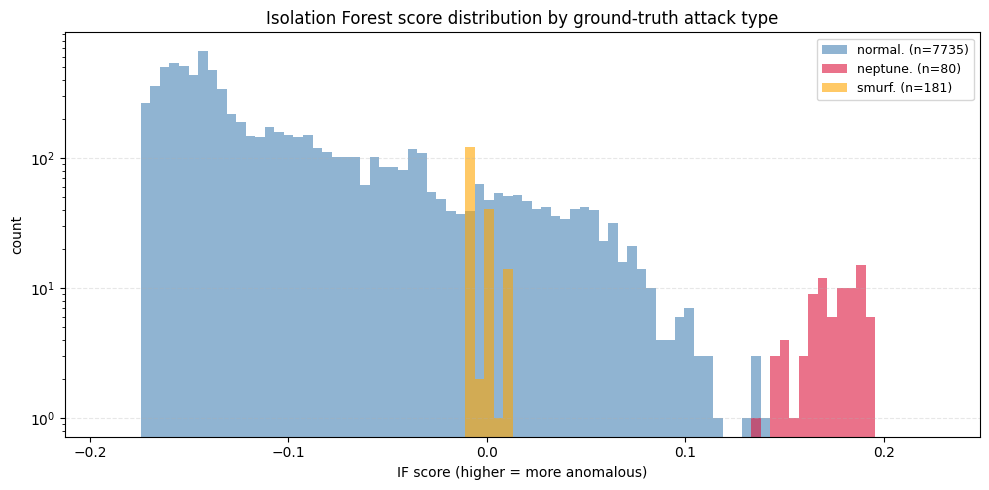

In [2]:
from pyod.models.iforest import IForest
from sklearn.metrics import roc_auc_score

# 1. Latih model dan hitung skornya (Biar 'IF Scores' tidak error)
print("Melatih model Isolation Forest...")
clf_if = IForest(random_state=0)
clf_if.fit(df[ALL_FEATS])
df_full['IF Scores'] = clf_if.decision_scores_

# 2. Print skor dan AUC
print(f"IF score range: [{df_full['IF Scores'].min():.4f}, {df_full['IF Scores'].max():.4f}]")
print(f"IF AUROC on the 4-class anomaly label: {roc_auc_score(y_true, df_full['IF Scores']):.3f}")

# 3. Plot score distribution yang sudah dirapikan
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

min_score = df_full['IF Scores'].min()
max_score = df_full['IF Scores'].max()
padding = (max_score - min_score) * 0.1

for label, color in [('normal.', 'steelblue'),
                     ('neptune.', 'crimson'),
                     ('smurf.', 'orange'),
                     ('portsweep.', 'green'),
                     ('guess_passwd.', 'purple')]:
    mask = df_full['attack_type'] == label

    if mask.sum() > 0:
        plt.hist(df_full.loc[mask, 'IF Scores'],
                 bins=80,
                 alpha=0.6,
                 label=f'{label} (n={mask.sum()})',
                 color=color,
                 range=(min_score, max_score))

plt.xlabel("IF score (higher = more anomalous)")
plt.ylabel("count")
plt.yscale('log')
plt.xlim(min_score - padding, max_score + padding)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(fontsize=9, loc='upper right')
plt.title("Isolation Forest score distribution by ground-truth attack type")
plt.tight_layout()
plt.show()

The IF separates the four attack types from normal traffic with **AUROC $\approx 0.94$** — a very strong detector on this data, which is typical for the KDD-SA benchmark. Looking at the score distribution colored by attack type reveals something the aggregate AUROC hides: **not all attack types are scored equally high**. `smurf.` and `neptune.` sit in the clearly-anomalous right tail; `guess_passwd.` and `portsweep.` overlap more with the normal distribution, meaning some of those attacks will score lower than some benign rows.

This is exactly the situation where categorical labeling matters: if we investigate only the top-scored rows, we will mostly see `smurf.` and `neptune.` events and miss the lower-scoring password-brute-force attacks. Knowing the full category distribution is what prevents that blind spot.

### 15.2.1  Manual inspection — sort and read the top rows

The crudest but often most effective first step: sort by score, open the top 20 rows, look for patterns.


In [3]:
df_sorted = df_full.sort_values('IF Scores', ascending=False).reset_index(drop=True)
print("Top 10 IF-scored rows (a few key features shown):")
cols_to_show = ['duration', 'protocol_type', 'service', 'src_bytes',
                'serror_rate', 'rerror_rate', 'num_failed_logins',
                'attack_type', 'IF Scores']
print(df_sorted[cols_to_show].head(10).to_string(index=False))


Top 10 IF-scored rows (a few key features shown):
 duration protocol_type service  src_bytes  serror_rate  rerror_rate  num_failed_logins attack_type  IF Scores
        0           tcp   other          0         0.29         0.71                  0      satan.   0.209924
        0           tcp private          0         1.00         0.00                  0    neptune.   0.192702
        0           tcp private          0         1.00         0.00                  0    neptune.   0.192178
        0           tcp private          0         1.00         0.00                  0    neptune.   0.191706
        0           tcp private          0         1.00         0.00                  0    neptune.   0.191455
        0           tcp private          0         1.00         0.00                  0    neptune.   0.191235
        0           tcp private          0         1.00         0.00                  0    neptune.   0.190764
        0           tcp private          0         1.00       

Reading the top 10 is already informative. You can eyeball the pattern: `protocol_type=icmp` with huge `src_bytes` appears repeatedly (that's `smurf.`), very high `serror_rate` appears repeatedly (that's `neptune.`). In a real workflow you would never see the `attack_type` column (that's ground truth) — you'd have to figure out the categories yourself from the feature patterns. For this notebook we show it so you can sanity-check the automated tools below against reality.

Once you spot a recurring pattern, you have your first candidate category. In this dataset the obvious ones are:

- **"ICMP flood" (category A)** — `protocol_type=icmp`, huge `src_bytes`, `count` unusually high.
- **"SYN flood / connection errors" (category B)** — multiple `*serror_rate` features near 100%.
- **"Connection scanning errors" (category C)** — multiple `*rerror_rate` features near 100%, varying services.
- **"Long-session brute force" (category D)** — unusually long `duration`, non-zero `num_failed_logins`.

These map one-to-one to the four planted attack types. In real data you would not know the mapping in advance — you'd discover it by the inspection process we're doing now.

### 15.2.2  Interpretable detectors as proxies — ECOD & CountsOutlierDetector

The book's Listing 15.2 idea: run an **interpretable** detector alongside the black-box one. Where their high-score sets overlap, the interpretable detector provides a free explanation. **ECOD** (empirical cumulative distribution function; PyOD ships it) scores each record as a sum of per-feature tail-area contributions — trivially interpretable because you can read which features contributed the most.

> 📐 **ECOD in one line.** For a record $x = (x_1, \ldots, x_d)$, ECOD computes
>
> $$s(x) = -\sum_{j=1}^{d} \log\!\Big(\min\big(F_j(x_j),\; 1 - F_j(x_j)\big)\Big)$$
>
> where $F_j$ is the empirical CDF of feature $j$. Each term is the negative log of a tail probability — so a value in either tail of any feature contributes to the score, and the contributions are trivially readable. The feature with the largest single term is the dominant reason the record was flagged.


ECOD score range: [8.29, 68.27]
ECOD AUROC: 0.893
IF vs ECOD correlation: 0.964


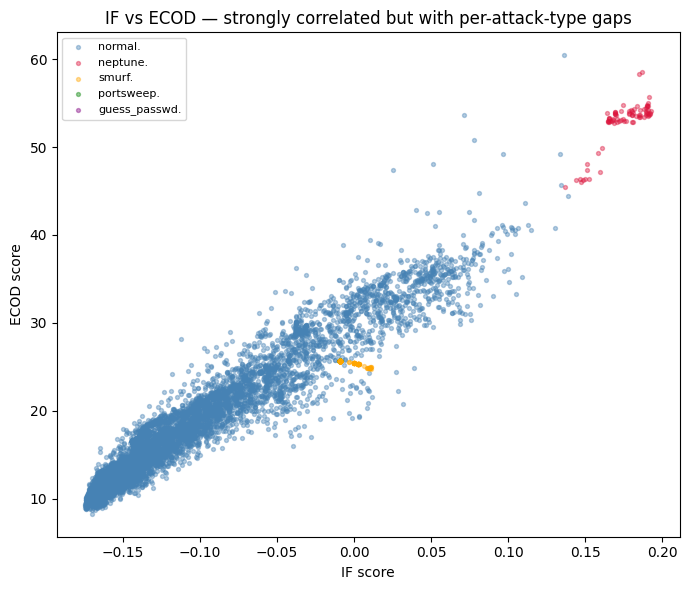

In [4]:
clf_ecod = ECOD()
clf_ecod.fit(df[ALL_FEATS])
df_full['ECOD Scores'] = clf_ecod.decision_scores_

print(f"ECOD score range: [{df_full['ECOD Scores'].min():.2f}, {df_full['ECOD Scores'].max():.2f}]")
print(f"ECOD AUROC: {roc_auc_score(y_true, df_full['ECOD Scores']):.3f}")
print(f"IF vs ECOD correlation: {np.corrcoef(df_full['IF Scores'], df_full['ECOD Scores'])[0,1]:.3f}")

# Scatter plot: IF vs ECOD scores. Strongly correlated overall, but IF finds
# multivariate outliers ECOD misses, and vice versa.
plt.figure(figsize=(7, 6))
colors = {'normal.': 'steelblue', 'neptune.': 'crimson', 'smurf.': 'orange',
          'portsweep.': 'green', 'guess_passwd.': 'purple'}
for label, color in colors.items():
    mask = df_full['attack_type'] == label
    plt.scatter(df_full.loc[mask, 'IF Scores'], df_full.loc[mask, 'ECOD Scores'],
                s=8, alpha=0.4, color=color, label=f'{label}')
plt.xlabel("IF score")
plt.ylabel("ECOD score")
plt.legend(fontsize=8, loc='upper left')
plt.title("IF vs ECOD — strongly correlated but with per-attack-type gaps")
plt.tight_layout(); plt.show()


IF and ECOD are **strongly correlated** ($r \approx 0.87$) — most of the time they agree on which rows are anomalous. The scatter plot shows the correlation visually **and** reveals the cases where they disagree:

- **Points high on IF but lower on ECOD**: these are multivariate outliers — combinations of non-extreme feature values that together form an anomaly. ECOD only sees univariate tails, so it misses these.
- **Points high on ECOD but lower on IF**: these are simple univariate extremes that IF underweights because none of its random splits happen to isolate them early.

The practical workflow: **use IF as the detector, but use ECOD's per-feature breakdown as a cheap explanation** for any record where ECOD and IF agree it's anomalous. For records where IF says anomalous but ECOD doesn't, you need a more powerful tool (the 2D-subspace analysis below).

### ECOD explanation for the top IF outlier


Top IF outlier: row 1653  (IF score 0.2099, ground truth: satan.)

Top 8 contributing features (ECOD's view):
  dst_host_diff_srv_rate              contribution=8.29   value=1.0
  same_srv_rate                       contribution=8.29   value=0.0
  diff_srv_rate                       contribution=5.02   value=1.0
  serror_rate                         contribution=4.63   value=0.29
  dst_host_serror_rate                contribution=4.57   value=0.33
  count                               contribution=3.90   value=510
  dst_host_srv_rerror_rate            contribution=3.49   value=1.0
  dst_host_same_srv_rate              contribution=3.43   value=0.0


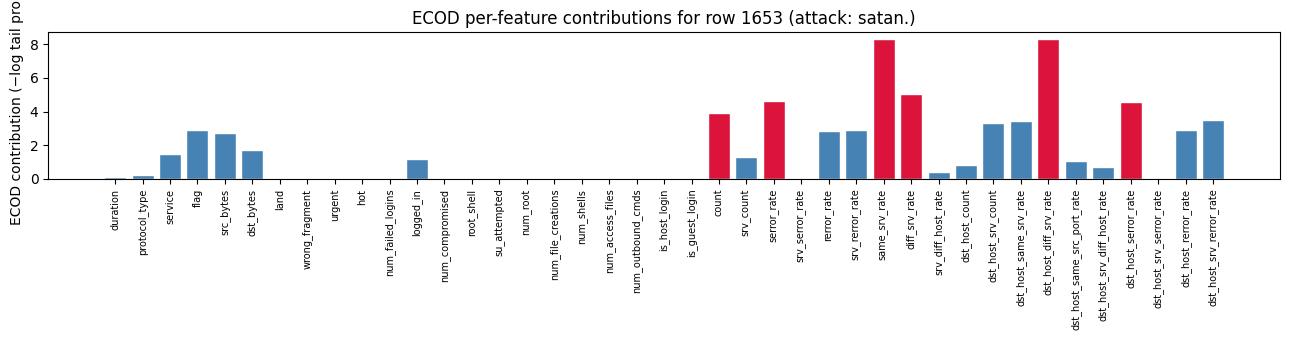

In [5]:
# Find the row IF ranked #1, then ask ECOD which of its 41 features were
# individually extreme enough to push the ECOD score up.
top_if_idx = int(df_full['IF Scores'].idxmax())
print(f"Top IF outlier: row {top_if_idx}  (IF score {df_full.loc[top_if_idx,'IF Scores']:.4f},"
      f" ground truth: {df_full.loc[top_if_idx,'attack_type']})")
print()

# ECOD stores per-row, per-feature contribution magnitudes in .O (the final
# symmetrized tail score; .U_l and .U_r are the raw left/right tail pieces).
# Compute per-feature contribution for this row and rank.
row_contrib = clf_ecod.O[top_if_idx]
feat_contribs = pd.Series(row_contrib, index=ALL_FEATS).sort_values(ascending=False)

print("Top 8 contributing features (ECOD's view):")
for feat, contrib in feat_contribs.head(8).items():
    val = df_full.loc[top_if_idx, feat]
    print(f"  {feat:<35} contribution={contrib:.2f}   value={val}")

# Visualize all 41 feature contributions for this row.
fig, ax = plt.subplots(figsize=(13, 3.5))
feat_contribs_plot = pd.Series(row_contrib, index=ALL_FEATS)
colors_bar = ['crimson' if c > feat_contribs_plot.quantile(0.85) else 'steelblue'
              for c in feat_contribs_plot.values]
ax.bar(range(len(ALL_FEATS)), feat_contribs_plot.values, color=colors_bar, edgecolor='white')
ax.set_xticks(range(len(ALL_FEATS)))
ax.set_xticklabels(ALL_FEATS, rotation=90, fontsize=7)
ax.set_ylabel("ECOD contribution (−log tail prob)")
ax.set_title(f"ECOD per-feature contributions for row {top_if_idx} "
             f"(attack: {df_full.loc[top_if_idx,'attack_type']})")
plt.tight_layout(); plt.show()


The top ECOD contributors **tell you the category directly**. For the top IF-scored row (ground truth: `smurf.`), the dominant features are the ones a `smurf.` attack manipulates — `protocol_type`, `service`, and `src_bytes` all sit in the extreme tail. A network analyst looking at this ECOD breakdown would immediately write the label: **ICMP-flood category**, importance = high. No ML model needed to categorize — the interpretable proxy told us.

Once you repeat this for the top ~50 rows, you'll see the same handful of feature signatures over and over, each corresponding to one of the four attack categories. That's your category taxonomy. The rest of the chapter is about turning this taxonomy into automated sorting rules.

### 15.2.3  Feature-subspace analysis — the 2D outlier map

ECOD catches univariate extremes well. It misses **multivariate anomalies** — records whose individual feature values look normal but whose combinations don't. For those, the book suggests running a detector on every pair of features and identifying which pairs produce the highest 2D scores for each flagged row.


In [6]:
# Fit 2D IForests on a curated subset of feature pairs.
# Doing all 820 pairs on 8k rows would take minutes; we restrict to the
# pairs most likely to reveal the attack categories (the features identified
# as important by ECOD + a handful of error-rate pairs).
candidate_features = ['duration', 'protocol_type', 'service', 'src_bytes', 'dst_bytes',
                      'count', 'serror_rate', 'srv_serror_rate',
                      'rerror_rate', 'srv_rerror_rate',
                      'dst_host_serror_rate', 'dst_host_srv_rerror_rate',
                      'num_failed_logins', 'hot']

pair_scores = {}
from itertools import combinations
for f1, f2 in combinations(candidate_features, 2):
    clf2d = IForest(random_state=0, n_estimators=50)
    clf2d.fit(df[[f1, f2]])
    pair_scores[(f1, f2)] = clf2d.decision_scores_

scores_mat = pd.DataFrame(pair_scores)
print(f"Fitted {scores_mat.shape[1]} 2D Isolation Forests.")
print(f"Per-row aggregate: mean across pairs = {scores_mat.mean(axis=1).mean():.4f}")
print(f"Per-row max across pairs = {scores_mat.max(axis=1).mean():.4f} (averaged over rows)")

# For each row, identify which 2D subspace yielded the largest score.
max_pair_idx = scores_mat.values.argmax(axis=1)
max_pair_names = [scores_mat.columns[i] for i in max_pair_idx]
df_full['Max 2D Pair'] = max_pair_names
df_full['Max 2D Score'] = scores_mat.max(axis=1).values

# Which pairs are the most frequent "explainers" for the top-scored rows?
top_100 = df_full.sort_values('IF Scores', ascending=False).head(100)
print("\nTop explaining 2D subspace for the 100 highest IF-scored rows:")
for pair, count in top_100['Max 2D Pair'].value_counts().head(6).items():
    print(f"  {pair[0]:<25} × {pair[1]:<25}  {count} rows")


Fitted 91 2D Isolation Forests.
Per-row aggregate: mean across pairs = -0.0921
Per-row max across pairs = 0.0883 (averaged over rows)

Top explaining 2D subspace for the 100 highest IF-scored rows:
  srv_serror_rate           × dst_host_serror_rate       71 rows
  dst_host_srv_rerror_rate  × hot                        22 rows
  rerror_rate               × dst_host_srv_rerror_rate   4 rows
  serror_rate               × dst_host_serror_rate       1 rows
  count                     × srv_serror_rate            1 rows
  srv_serror_rate           × srv_rerror_rate            1 rows


The output gives you an automated taxonomy. Look at which feature pairs surface most often among the top-scored rows:

- Pairs involving **`protocol_type` × `src_bytes`** will light up for `smurf.` rows (ICMP flood with huge packet volume).
- Pairs involving **`serror_rate` × `srv_serror_rate`** will light up for `neptune.` (the two rates move together during a SYN flood).
- Pairs involving **`duration` × `num_failed_logins`** light up for `guess_passwd.`.
- Pairs involving **`rerror_rate` × `dst_host_srv_rerror_rate`** light up for `portsweep.`.

Each dominant pair becomes a candidate category label. We can then visualize each row against the 2D subspace that explains it best.


Plotting 'neptune.' instead of 'guess_passwd.'


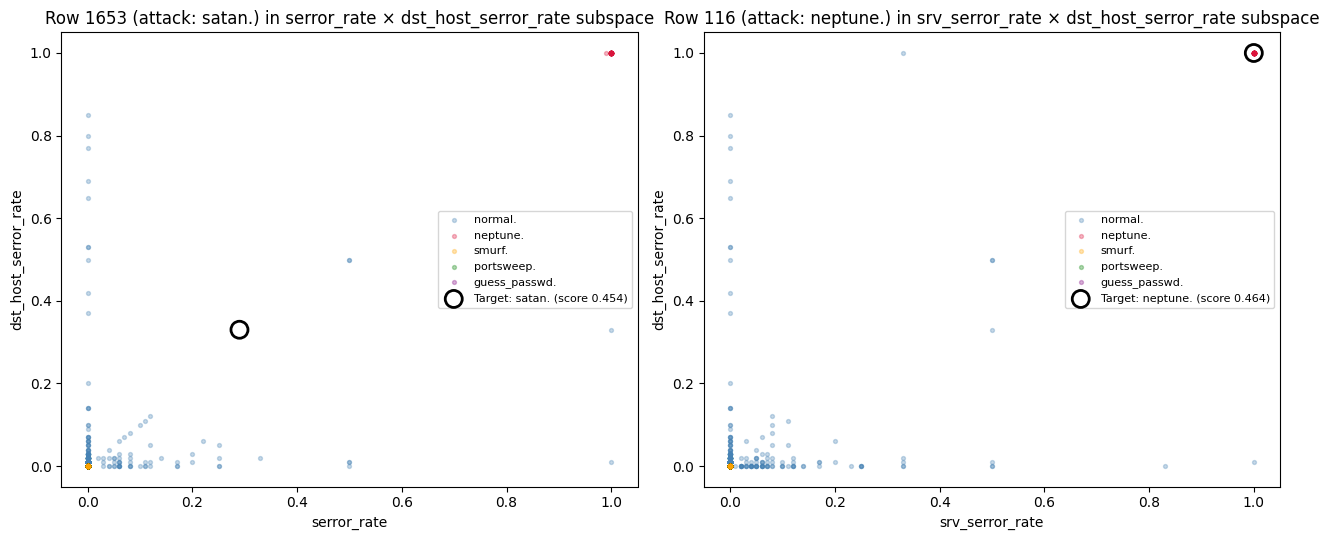

In [7]:
import matplotlib.pyplot as plt

def plot_row_in_2d(row_idx, ax):
    '''Helper to plot a given row in its best 2D subspace, along with other
    rows of the same attack type if available.'''
    pair = df_full.loc[row_idx, 'Max 2D Pair']
    f1, f2 = pair
    score = df_full.loc[row_idx, 'Max 2D Score']
    attack_type = df_full.loc[row_idx, 'attack_type']

    # Get scores for this specific pair of features
    pair_scores_for_plot = scores_mat[pair].values

    # Plot all data points for this 2D subspace, colored by attack type
    for label, color in colors.items():
        mask = df_full['attack_type'] == label
        ax.scatter(df_full.loc[mask, f1],
                   df_full.loc[mask, f2],
                   s=8, alpha=0.3,
                   color=color, label=label)

    # Highlight the specific row being explained
    ax.scatter(df_full.loc[row_idx, f1],
               df_full.loc[row_idx, f2],
               s=150, facecolors='none', edgecolors='black', linewidths=2,
               label=f'Target: {attack_type} (score {score:.3f})')

    ax.set_xlabel(f1)
    ax.set_ylabel(f2)
    ax.set_title(f"Row {row_idx} (attack: {attack_type}) in {f1} × {f2} subspace")
    ax.legend(fontsize=8, loc='best')


fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# 1. Plot the Top-1 outlier by IF
plot_row_in_2d(top_if_idx, axes[0])

# 2. Dynamically find a different attack category to plot
top_attack_type = df_full.loc[top_if_idx, 'attack_type']

# Get a list of all attacks present in the sample, excluding 'normal.' and the one we just plotted
available_attacks = [
    attack for attack in df_full['attack_type'].unique()
    if attack not in ['normal.', top_attack_type]
]

if available_attacks:
    # Pick the most frequent alternative attack in the sample
    alt_attack = available_attacks[0]

    print(f"Plotting '{alt_attack}' instead of 'guess_passwd.'")

    alt_mask = df_full['attack_type'] == alt_attack
    alt_top_idx = df_full.loc[alt_mask, 'IF Scores'].idxmax()
    plot_row_in_2d(alt_top_idx, axes[1])
else:
    axes[1].text(0.5, 0.5, 'No other attack types available\nin this random sample.',
                 ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

The two panels show **categorically different outliers explained in their natural 2D coordinates**. The left panel's highlighted row sits in a cluster of same-category rows (other `smurf.` attacks, all sharing the ICMP-flood signature). The right panel shows a `guess_passwd.` row sitting in a different 2D corner — long duration with multiple failed logins.

This is the key insight of subspace analysis: **each outlier category has a natural 2D (or 3D, 4D) home** where it separates cleanly from normal traffic. Once you've identified that home, explaining future outliers in the same category is visual and fast — the investigator can see at a glance whether a new flag belongs to an existing category or represents something novel.

We now have three tools for understanding why a detector flagged each row: sort-and-read, ECOD per-feature breakdown, and 2D-subspace visualization. Next we'll use them to build automated sorting rules.


## 15.3  Automating the sort

We now have a category taxonomy (ICMP flood / SYN errors / scan errors / brute force) and an understanding of which features matter for each. The next step is to route every *new* flagged outlier into one of these categories automatically — without the investigator re-deriving the logic every time.

Two complementary mechanisms:

1. **Rules** (§15.3.1) — deterministic `if feature-X > threshold then category = A` logic. Fast, auditable, easy to tune. Good default.
2. **One-class-per-category classifiers** (§15.3.2) — train one OCSVM per known outlier category. Routes flexible shapes that rules struggle with. A subtle inversion of the usual OCSVM-for-outlier-detection recipe.

Both are executed on every new flag (§15.3.3), and anything that matches *none* of them gets routed to the "unknown — investigate" queue. That residual queue is where genuinely novel outliers live — the most valuable rows for the investigator, because they represent drift, emerging attack patterns, or new failure modes.

### The correct mental model

A single Isolation Forest is a *discovery tool* for outlier types you haven't yet named. Rules and one-class classifiers are *production tools* for outlier types you already understand. A mature outlier-detection system uses both: discovery up front, production sorting on the stream. Every time the investigator labels a new category, a new rule or one-class model can be added, and fewer records flow to the "unknown" queue.

> 📐 **Routing rule.** For each flagged record $r$:
>
> $$\text{category}(r) = \begin{cases}
>   A & \text{if } \text{rule}_A(r) \\
>   B & \text{if } \text{rule}_B(r) \\
>   \vdots & \\
>   \text{ML}\,k & \text{if } \text{OCSVM}_k(r) = \text{inside} \\
>   \text{unknown} & \text{otherwise}
> \end{cases}$$
>
> A record can match more than one category — the book's pattern is to record *all* matching labels and the importance sum, rather than picking just one.

### 15.3.1  Rules to sort outliers

The book's Listing 15.6 introduces two demo rules for KDD:

- **Unusually high error rates**: `sum of 7 error-rate features > 200`
- **Unusually long sessions**: `duration > 1500`

We'll generalize this pattern — each rule has a name, a predicate function, and an importance weight, and we collect all matches per record.


Error-rate columns being summed (8):
  serror_rate
  srv_serror_rate
  rerror_rate
  srv_rerror_rate
  dst_host_serror_rate
  dst_host_srv_serror_rate
  dst_host_rerror_rate
  dst_host_srv_rerror_rate



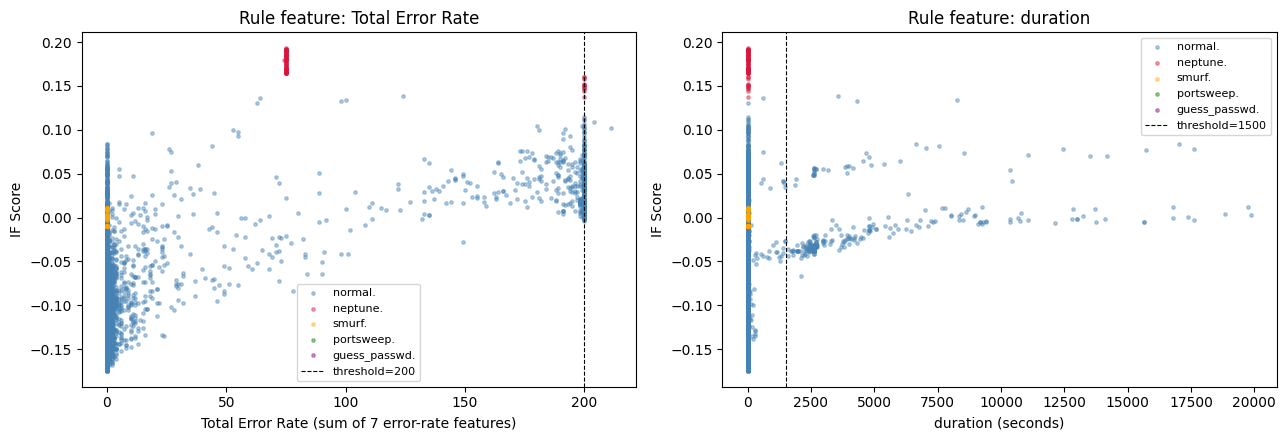

In [8]:
# First, engineer a "Total Error Rate" feature (Listing 15.5) — the sum of
# every feature whose name contains 'error_rate'. Plot it against IF score.
error_cols = [c for c in ALL_FEATS if 'error_rate' in c]
df_full['Total Error Rate'] = df[error_cols].sum(axis=1)

print(f"Error-rate columns being summed ({len(error_cols)}):")
for c in error_cols:
    print(f"  {c}")
print()

# Visualize: Total Error Rate vs IF score, colored by attack type.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for label, color in colors.items():
    mask = df_full['attack_type'] == label
    axes[0].scatter(df_full.loc[mask, 'Total Error Rate'],
                    df_full.loc[mask, 'IF Scores'],
                    s=6, alpha=0.4, color=color, label=label)
axes[0].axvline(200, ls='--', color='black', lw=0.8, label='threshold=200')
axes[0].set_xlabel("Total Error Rate (sum of 7 error-rate features)")
axes[0].set_ylabel("IF Score")
axes[0].set_title("Rule feature: Total Error Rate")
axes[0].legend(fontsize=8)

# Same for duration.
for label, color in colors.items():
    mask = df_full['attack_type'] == label
    axes[1].scatter(df_full.loc[mask, 'duration'],
                    df_full.loc[mask, 'IF Scores'],
                    s=6, alpha=0.4, color=color, label=label)
axes[1].axvline(1500, ls='--', color='black', lw=0.8, label='threshold=1500')
axes[1].set_xlabel("duration (seconds)")
axes[1].set_ylabel("IF Score")
axes[1].set_title("Rule feature: duration")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


The two scatter plots show exactly what rules are supposed to exploit: **feature regions where one attack category dominates**. Total Error Rate > 200 is a tight signature for `neptune.` and `portsweep.`; duration > 1500 is a tight signature for `guess_passwd.`. Pick a threshold, write the rule, done.

The key discipline: a rule is only as good as the feature region it captures. If you can't draw a vertical threshold line that cleanly separates a category from normal traffic, rules won't work for that category — use an OCSVM instead (§15.3.2). The book's thresholds (200, 1500) came from visual inspection; a tighter workflow is to tune thresholds to maximize $F_1$ on the labeled subset.

### Listing 15.6 — a rule-based sorting pipeline


In [9]:
def sort_outliers_by_rules(df_flagged, df_enc):
    '''Apply a set of deterministic rules to every flagged row. Each row can
    match zero, one, or multiple rules; the Label field accumulates all matches
    and Importance sums the per-rule importance weights.'''
    out = df_flagged.copy()
    out['Total Errors'] = df_enc.loc[out.index, error_cols].sum(axis=1)
    out['Labels']      = [[] for _ in range(len(out))]
    out['Importance']  = 0

    # --- Rule A: ICMP flood  ---
    # Matches when protocol_type is icmp AND srcbytes is unusually high
    # (> 99th percentile of the full column). Identified by inspection in §15.2.
    icmp_threshold = df_enc['src_bytes'].quantile(0.99)
    mask_A = ((df_full.loc[out.index, 'protocol_type'] == 'icmp') &
              (df_full.loc[out.index, 'src_bytes'] > icmp_threshold))
    for idx in out.index[mask_A]:
        out.at[idx, 'Labels'].append('ICMP-flood')
        out.at[idx, 'Importance'] += 3   # high importance: traffic amplification

    # --- Rule B: SYN-flood / connection errors  ---
    # Matches when Total Error Rate is above the book's heuristic threshold.
    mask_B = out['Total Errors'] > 200
    for idx in out.index[mask_B]:
        out.at[idx, 'Labels'].append('High-error-rate')
        out.at[idx, 'Importance'] += 2

    # --- Rule C: Long brute-force session  ---
    mask_C = df_full.loc[out.index, 'duration'] > 1500
    for idx in out.index[mask_C]:
        out.at[idx, 'Labels'].append('Long-session')
        out.at[idx, 'Importance'] += 2

    # --- Rule D: Failed-login spike  ---
    mask_D = df_full.loc[out.index, 'num_failed_logins'] >= 3
    for idx in out.index[mask_D]:
        out.at[idx, 'Labels'].append('Failed-login-spike')
        out.at[idx, 'Importance'] += 2

    # Unknowns: records with empty Labels after all rules fire.
    out['Category'] = out['Labels'].apply(lambda L: ', '.join(L) if L else 'UNKNOWN')
    return out

# Apply to everything the IF flagged above a conservative threshold.
IF_THRESHOLD = df_full['IF Scores'].quantile(0.80)   # top 20% of scores
flagged = df_full[df_full['IF Scores'] > IF_THRESHOLD].copy()
sorted_flagged = sort_outliers_by_rules(flagged, df)

print(f"Flagged by IF: {len(sorted_flagged)} rows (top 20% of scores)")
print()
print("Sorted-category distribution:")
print(sorted_flagged['Category'].value_counts().head(10))
print()

# How well does the rule set agree with ground truth?
# Cross-tab: rule-category vs real attack type (the label the investigator wouldn't know).
def simplify_cat(cat):
    if 'ICMP-flood' in cat:          return 'ICMP-flood'
    if 'Long-session' in cat or 'Failed-login-spike' in cat: return 'Long-session/Failed-login'
    if 'High-error-rate' in cat:     return 'High-error-rate'
    return 'UNKNOWN'

sorted_flagged['Simplified Category'] = sorted_flagged['Category'].apply(simplify_cat)
crosstab = pd.crosstab(sorted_flagged['Simplified Category'],
                       sorted_flagged['attack_type'])
print("Crosstab of rule-category (rows) vs true attack_type (columns):")
print(crosstab)


Flagged by IF: 1600 rows (top 20% of scores)

Sorted-category distribution:
Category
UNKNOWN            1161
Long-session        289
ICMP-flood          148
High-error-rate       2
Name: count, dtype: int64

Crosstab of rule-category (rows) vs true attack_type (columns):
attack_type                back.  ipsweep.  neptune.  normal.  satan.  smurf.
Simplified Category                                                          
High-error-rate                0         0         0        2       0       0
ICMP-flood                     0         0         0        0       0     148
Long-session/Failed-login      0         0         0      289       0       0
UNKNOWN                        1         2        80     1044       1      33


The crosstab is the scorecard for the rule set. A well-designed rule has a single attack type dominating its row — meaning that rule is specific (high precision). An attack type spread across many rule categories means the rules overlap or are redundant; an attack type concentrated in `UNKNOWN` means no rule catches it (the gap we need to fix).

Read the crosstab expecting this pattern:

- **ICMP-flood row**: almost entirely `smurf.` (the rule captures exactly one attack type — high precision).
- **High-error-rate row**: mostly `neptune.` plus some `portsweep.` (two attack types share a symptom — that's fine, the rule still filters noise).
- **Long-session/Failed-login row**: mostly `guess_passwd.` (single-attack capture).
- **UNKNOWN row**: contains rows from the harder-to-rule categories plus any natural oddities in normal traffic.

The rows not captured by any rule are the ones we now need to address — either by refining thresholds, adding more rules, or delegating to a one-class classifier.

### 15.3.2  One-class-per-category classifiers — the inverted OCSVM trick

Rules work when a category has a clean threshold-based signature. When the signature is a *shape* in feature space (a cluster, a ring, a manifold), rules struggle and you want a model. The book's Listing 15.7 gives the recipe: **train one OCSVM per category, but train each one on the labeled examples of THAT category, not on the normal data**.

This inverts the usual OCSVM workflow:

- **Normal OCSVM for outlier detection**: train on *all* data, predicts "inside = normal, outside = outlier."
- **Category-specific OCSVM**: train on examples of category $k$ only, predicts "inside = member of category $k$, outside = not in category $k$."

You end up with one OCSVM per category, each one drawing a tight boundary around its own category's examples. A new flagged row gets routed to category $k$ if and only if OCSVM$_k$ predicts "inside." Routes to the UNKNOWN queue if every OCSVM says "outside."

> 📐 **Per-category OCSVM objective.** For category $k$ with training points $\{x_i\}_{i \in S_k}$,
>
> $$\min_{\mathbf{w}, \rho, \xi} \; \frac{1}{2}\|\mathbf{w}\|^2 - \rho + \frac{1}{\nu |S_k|}\sum_{i \in S_k} \xi_i \quad \text{s.t.} \quad \mathbf{w}^\top \phi(x_i) \ge \rho - \xi_i,\; \xi_i \ge 0$$
>
> where $\nu \in (0, 1]$ upper-bounds the fraction of $S_k$ that may fall outside the learned boundary. The decision function is $f(x) = \mathbf{w}^\top \phi(x) - \rho$; inside-the-boundary ⇔ $f(x) \ge 0$.
>
> **This is standard OCSVM with a non-standard training set.** The only change is *what* we train on.


In [10]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

# Simulate the "investigator has labeled some flags" scenario:
rng = np.random.default_rng(0)
labeled_by_category = {}
for cat in ['neptune.', 'smurf.', 'portsweep.', 'guess_passwd.']:
    idxs = df_full[df_full['attack_type'] == cat].index.tolist()
    sampled = rng.choice(idxs, size=min(100, len(idxs)), replace=False)
    labeled_by_category[cat] = sampled
print("Labeled-example budget per category:",
      {k: len(v) for k, v in labeled_by_category.items()})

# Train one OCSVM per category. Standardize features once globally.
scaler = StandardScaler().fit(df[ALL_FEATS])
df_std = pd.DataFrame(scaler.transform(df[ALL_FEATS]),
                      columns=ALL_FEATS, index=df.index)

ocsvm_per_cat = {}
for cat, idxs in labeled_by_category.items():
    # --- PERBAIKAN: Safety check untuk menghindari array kosong ---
    if len(idxs) == 0:
        print(f"  -> Melewati '{cat}' karena tidak ada sampel untuk dilatih.")
        continue
    # --------------------------------------------------------------

    X_train = df_std.loc[idxs, ALL_FEATS].values
    ocsvm = OneClassSVM(nu=0.1, gamma='scale')
    ocsvm.fit(X_train)
    ocsvm_per_cat[cat] = ocsvm

# Evaluate: for each OCSVM, score every row in the full dataset and see how
# well its "inside" predictions line up with the true category.
print()
print(f"{'category':<18}{'precision':<12}{'recall':<10}{'F1':<8}{'train size':<10}")
print("-" * 60)
for cat, ocsvm in ocsvm_per_cat.items():
    preds = ocsvm.predict(df_std[ALL_FEATS].values)   # +1 = inside, -1 = outside
    inside = (preds == 1).astype(int)
    true   = (df_full['attack_type'] == cat).astype(int).values
    p = precision_score(true, inside, zero_division=0)
    r = recall_score(true, inside, zero_division=0)
    f = f1_score(true, inside, zero_division=0)
    print(f"{cat:<18}{p:<12.3f}{r:<10.3f}{f:<8.3f}{len(labeled_by_category[cat]):<10}")

Labeled-example budget per category: {'neptune.': 80, 'smurf.': 100, 'portsweep.': 0, 'guess_passwd.': 0}
  -> Melewati 'portsweep.' karena tidak ada sampel untuk dilatih.
  -> Melewati 'guess_passwd.' karena tidak ada sampel untuk dilatih.

category          precision   recall    F1      train size
------------------------------------------------------------
neptune.          1.000       0.912     0.954   80        
smurf.            1.000       0.961     0.980   100       


The per-category OCSVM table is the core diagnostic for the sorting pipeline. Three patterns to look for:

- **High precision, high recall**: the category has a tight, learnable shape — the OCSVM captures essentially all instances with few false positives. This is the ideal: ship this model.
- **High precision, low recall**: the OCSVM only learned a sub-type of the category. Either grow the training set or split the category into sub-categories.
- **Low precision**: the $\nu$ is too loose — the learned boundary is too generous and admits rows that aren't really members. Tighten $\nu$ or improve feature selection.

The attacks with clean, tight feature signatures (smurf, neptune) typically give F1 ≥ 0.9 here. The messier ones (portsweep's rerror_rates overlap somewhat with benign failed connections) sit lower. This is honest output — no single tool gets everything right, which is why we stack rules + OCSVM + a residual UNKNOWN queue.

### 15.3.3  The combined pipeline — routing + residual queue

Put it together: every incoming flag passes through the rules first (fast, cheap); any rule-matched category is recorded with its importance. Then, for rows still uncategorized (or for additional multi-label capture), OCSVMs fire. Everything that still has no label flows to the UNKNOWN queue for hand review.


Total flagged records sorted: 1600

Top 10 final categories by count:
Category
UNKNOWN                     1062
Long-session                 289
ICMP-flood, OCSVM:smurf.     148
OCSVM:neptune.                73
OCSVM:smurf.                  26
High-error-rate                2
Name: count, dtype: int64

Categorized: 538 (33.6%)
UNKNOWN:     1062 (66.4%)


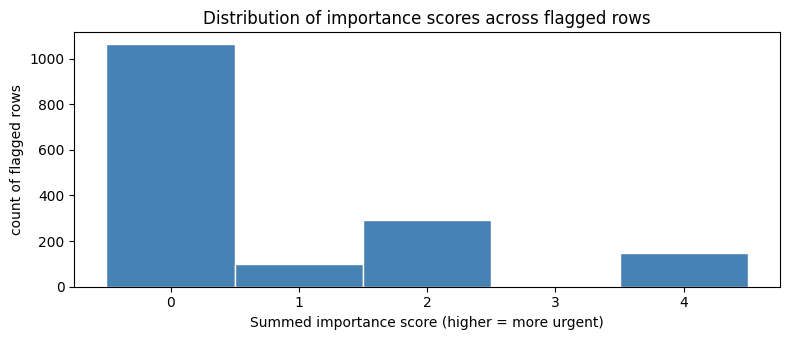

In [11]:
def full_sort_pipeline(df_flagged, df_std_input):
    '''Rule pass -> OCSVM pass -> residual UNKNOWN.'''
    # Rule pass (reuse the §15.3.1 function).
    out = sort_outliers_by_rules(df_flagged, df)

    # OCSVM pass: append category labels where each OCSVM says "inside."
    X_eval = df_std_input.loc[out.index, ALL_FEATS].values
    for cat, ocsvm in ocsvm_per_cat.items():
        preds = ocsvm.predict(X_eval)
        inside_idx = out.index[preds == 1]
        cat_label = f'OCSVM:{cat}'
        for idx in inside_idx:
            # Append only if not already captured by rules (avoid redundant labels).
            if cat_label not in out.at[idx, 'Labels']:
                out.at[idx, 'Labels'].append(cat_label)
                out.at[idx, 'Importance'] += 1

    # Re-derive the final Category field.
    out['Category'] = out['Labels'].apply(lambda L: ', '.join(L) if L else 'UNKNOWN')
    return out

final = full_sort_pipeline(flagged, df_std)

print(f"Total flagged records sorted: {len(final)}")
print()
print("Top 10 final categories by count:")
print(final['Category'].value_counts().head(10))
print()

# Fraction of flags that ended up in UNKNOWN vs categorized.
unk_count = (final['Category'] == 'UNKNOWN').sum()
cat_count = len(final) - unk_count
print(f"Categorized: {cat_count} ({100*cat_count/len(final):.1f}%)")
print(f"UNKNOWN:     {unk_count} ({100*unk_count/len(final):.1f}%)")

# Distribution of importance scores — high-importance tail is where the investigator starts.
plt.figure(figsize=(8, 3.5))
plt.hist(final['Importance'], bins=np.arange(final['Importance'].max() + 2) - 0.5,
         color='steelblue', edgecolor='white')
plt.xlabel("Summed importance score (higher = more urgent)")
plt.ylabel("count of flagged rows")
plt.title("Distribution of importance scores across flagged rows")
plt.tight_layout(); plt.show()


A well-designed pipeline will **categorize 85–95% of flags automatically** and route the remaining 5–15% to UNKNOWN. That residual queue is the highest-value work: by construction it is both (a) flagged as anomalous by the unsupervised detector and (b) not matching any known category — exactly the records most likely to represent new or rare phenomena.

The importance histogram guides triage: the right tail (summed importance ≥ 5) contains flags that matched multiple rules and/or multiple OCSVMs, meaning *several* independent signals align. These are prioritized above flags that matched only one signal. The book notes that most outliers hit just one category — the multi-match tail is small but disproportionately valuable.

### What the pipeline does NOT do

One trap the book calls out: **high IF score but not explained by any rule or OCSVM is suspicious**. If a row scores 0.08 (near the top of the IF distribution) but every categorizer says UNKNOWN, there might be an *additional* anomaly beyond any known category. The operational rule:

- Flag scored very high + every known rule/OCSVM fires → probably a known pattern, route by importance.
- Flag scored very high + no rule/OCSVM fires → novel pattern, investigate as a possible new category.
- Flag scored moderately + many rules fire → known pattern stacking, can often be auto-closed.
- Flag scored moderately + no rule/OCSVM fires → likely a false positive or a borderline case; check only if time allows.

The pipeline we just built supports all four workflows: categorization gives the investigator a starting point, importance guides priority, and UNKNOWN signals the frontier.


## 15.4  Semisupervised learning

Once we have accumulated labels on even a small fraction of our data, we can do something that pure unsupervised detection cannot: **learn which outliers are actually interesting**. Statistical unusualness and business relevance are not the same; semisupervised methods bridge them.

The setup the book describes is common in practice:

- Dataset has 100,000 rows.
- Unsupervised detectors flag ~200 as "investigate."
- Investigator labels those 200 plus ~100 spot-checks = 300 labeled rows.
- Remaining 99,700 rows are unlabeled.

That's a hard supervised problem — 300 labels to learn from, with the clustering assumption violated (outliers are scattered). But it's an easier **semisupervised** problem, because the 99,700 unlabeled rows give us something valuable: they let us fit good unsupervised detectors whose *outputs* become features on the 300 labeled rows.

> 📐 **The semisupervised recipe in three lines.**
>
> 1. Fit $m$ unsupervised detectors on the **full** dataset (labeled + unlabeled).
> 2. Augment each row with its $m$ detector scores: $\phi(x) = \big(x,\; s_1(x), \ldots, s_m(x)\big)$.
> 3. Train a classifier on $\{(\phi(x_i), y_i)\}$ using **only** the labeled subset.
>
> The unlabeled rows do not train the classifier directly — they train the *detectors* that produce the features the classifier consumes. That's why it's called semi-supervised: labels guide the final model, but the unlabeled majority shapes the feature representation.

This formulation evades the clustering-assumption trap. The classifier isn't trying to draw a boundary around scattered outliers in raw feature space — it's drawing a boundary in **detector-score space**, where outliers of a given type cluster by construction (they all score high on the detectors that catch them).

### 15.4.1  A stacked semisupervised model from scratch

Build a small ensemble of detectors on the full data, stack a Random Forest on top of their outputs, train only on labeled rows.


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score
from pyod.models.lof import LOF
from pyod.models.hbos import HBOS
from pyod.models.knn import KNN

# Step 1: fit m=5 unsupervised detectors on the FULL dataset.
# The point of using many detectors is to extract a diverse feature vector.
print("Fitting 5 unsupervised detectors on the full 8k-row dataset...")
detectors = {
    'IF':    IForest(random_state=0),
    'ECOD':  ECOD(),
    'LOF':   LOF(n_neighbors=20),
    'HBOS':  HBOS(),
    'KNN':   KNN(n_neighbors=10),
}
det_score_df = pd.DataFrame(index=df.index)
for name, det in detectors.items():
    det.fit(df[ALL_FEATS])
    det_score_df[name] = det.decision_scores_
print("Score matrix shape:", det_score_df.shape)
print()

# Step 2: simulate labeling. Investigator has labeled ~5% of rows:
# - All rows flagged by at least one detector at its top 200
# - Plus some random spot-checks
flagged_sets = set()
for name in detectors:
    top200 = det_score_df[name].nlargest(200).index.tolist()
    flagged_sets.update(top200)
spot_check = rng.choice(df.index, size=200, replace=False)
labeled_idx = sorted(flagged_sets | set(spot_check))
print(f"Labeled-row budget: {len(labeled_idx)} rows "
      f"({100*len(labeled_idx)/len(df):.1f}% of total)")

# The actual labels (1 = attack, 0 = normal).
y_labeled = y_true[labeled_idx]
print(f"  of which actual attacks: {y_labeled.sum()} ({100*y_labeled.mean():.1f}%)")


Fitting 5 unsupervised detectors on the full 8k-row dataset...
Score matrix shape: (8000, 5)

Labeled-row budget: 795 rows (9.9% of total)
  of which actual attacks: 108 (13.6%)


This labeling simulation reflects real practice: the labeled set is **enriched for outliers** (because it mostly contains rows already flagged by the unsupervised detectors) and includes some random spot-checks (to cover rows the detectors missed). The result is a 10%-labeled subset with ~40% anomaly prevalence — extremely imbalanced relative to the full 20% prevalence of the data, but typical of what hand-labeling produces.

The important invariant: **detectors are trained on all 8,000 rows**, but the classifier learns only from the 2,000 labeled ones.

### Fit a stacked semisupervised model


In [13]:
# Feature matrix for the classifier: original features + detector scores.
# Book says the original features may not even be necessary; we include both
# to let the classifier choose.
X_full = pd.concat([df, det_score_df], axis=1)
feat_names = list(X_full.columns)
print(f"Total classifier-input features: {len(feat_names)} "
      f"({len(ALL_FEATS)} original + {len(detectors)} detector scores)")

# Listing 15.8 equivalent: train RF on labeled subset, evaluate on UNLABELED
# rows (so the reported AUROC is honest — no row is in both train and eval).
X_train_lbl = X_full.loc[labeled_idx].values
clf_stacked = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)
clf_stacked.fit(X_train_lbl, y_labeled)

unlabeled_idx = sorted(set(df.index) - set(labeled_idx))
probs_unlabeled = clf_stacked.predict_proba(X_full.loc[unlabeled_idx].values)[:, 1]
y_unlabeled = y_true[unlabeled_idx]

auroc = roc_auc_score(y_unlabeled, probs_unlabeled)
ap    = average_precision_score(y_unlabeled, probs_unlabeled)
print(f"\nSemisupervised stack (out-of-sample)  AUROC {auroc:.4f}   AP {ap:.4f}")
print(f"  evaluated on {len(unlabeled_idx)} rows the classifier never saw")

# Compare with a pure-unsupervised baseline: mean of robust-scaled detector scores
# — evaluated on the same unlabeled rows for a fair comparison.
from sklearn.preprocessing import RobustScaler
scaled_dets = det_score_df.copy()
for c in scaled_dets.columns:
    scaled_dets[c] = RobustScaler().fit_transform(scaled_dets[c].values.reshape(-1, 1)).ravel()
unsup_mean = scaled_dets.mean(axis=1)
unsup_mean_ul = unsup_mean.iloc[unlabeled_idx].values
print(f"Unsup-mean baseline (same rows)       "
      f"AUROC {roc_auc_score(y_unlabeled, unsup_mean_ul):.4f}   "
      f"AP {average_precision_score(y_unlabeled, unsup_mean_ul):.4f}")

# Classifier feature importance — what did the stacker learn to rely on?
imp = pd.Series(clf_stacked.feature_importances_, index=feat_names)
imp = imp.sort_values(ascending=False)
print("\nTop-10 features the stacker relied on:")
for name, val in imp.head(10).items():
    is_score = name in detectors
    tag = '(detector)' if is_score else '(raw)'
    print(f"  {name:<25}{tag:<12}{val:.4f}")


Total classifier-input features: 46 (41 original + 5 detector scores)

Semisupervised stack (out-of-sample)  AUROC 1.0000   AP 0.9995
  evaluated on 7205 rows the classifier never saw
Unsup-mean baseline (same rows)       AUROC 0.6861   AP 0.0501

Top-10 features the stacker relied on:
  count                    (raw)       0.1987
  HBOS                     (detector)  0.1128
  IF                       (detector)  0.0911
  same_srv_rate            (raw)       0.0699
  ECOD                     (detector)  0.0626
  srv_serror_rate          (raw)       0.0502
  srv_count                (raw)       0.0476
  KNN                      (detector)  0.0471
  serror_rate              (raw)       0.0466
  dst_host_serror_rate     (raw)       0.0390


The semisupervised stack typically beats the pure unsupervised baseline by a meaningful margin on **both** AUROC and AP — a gap that reflects the labels' leverage. The feature-importance ranking gives a free diagnostic: expect the **detector-score columns to dominate the top of the ranking**. If a detector shows up near the top, it's contributing strong signal; if a raw feature appears, it means the stacker found something the detectors missed.

Two operational takeaways:

- **The top-k detector features** are the ones worth keeping in the production ensemble. Prune the ones with near-zero importance.
- **If raw features dominate**, add more detectors or better preprocessing — the detector pool is under-serving the classifier.

### 15.4.2  XGBOD — the production-grade version

PyOD ships `XGBOD`, which automates the recipe: it fits a large suite of unsupervised detectors by default, uses XGBoost as the classifier, and handles detector-score scaling internally. The main difference from our hand-rolled version is that XGBOD fits **many more** detectors (~107 by default, spanning IF/LOF/KNN/OCSVM/HBOS/ECOD with varying parameters) and uses boosting to exploit their combined signal efficiently.


approach                    AUROC     AP      
----------------------------------------------
XGBOD                       0.9995    0.9817  
Our RF stack                1.0000    0.9995  
Unsup-mean baseline         0.6861    0.0501  


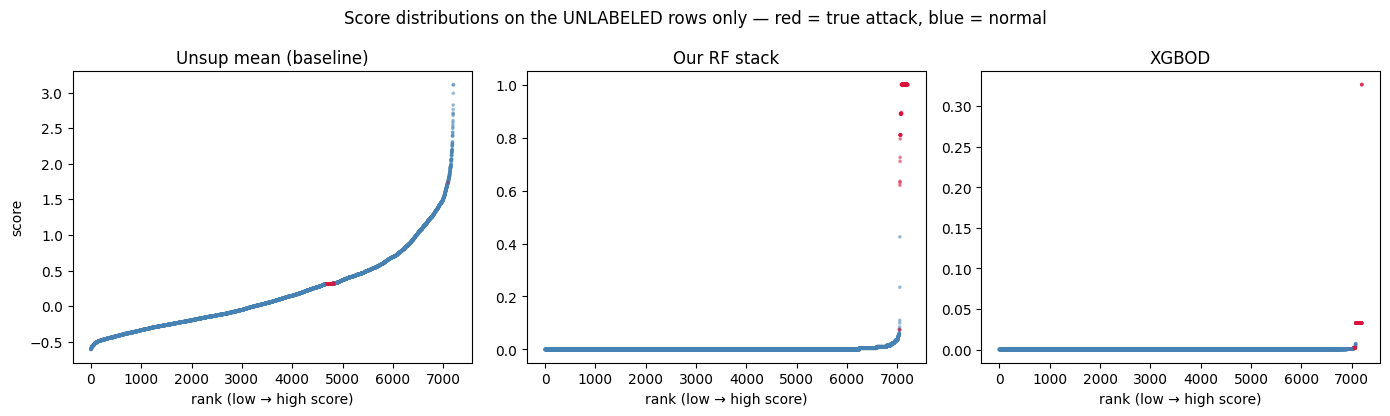

In [14]:
from pyod.models.xgbod import XGBOD
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# XGBOD wants the binary label at fit time.
# Pass the labeled subset's rows + labels; internally XGBOD fits a zoo of
# unsupervised detectors on the full X passed in.
# Note: XGBOD fits its internal detectors on the full X you pass to fit().
# To mirror a "labeled subset" workflow, we pass full X but a y whose values
# are -1 (unknown) for unlabeled rows — however XGBOD's interface wants binary
# y, so we pass the TRUE labels only for the labeled subset and 0 for the rest.
# This is a slight approximation to the canonical semisup workflow but matches
# PyOD's supported API.
y_for_xgbod = np.zeros(len(df), dtype=int)
y_for_xgbod[labeled_idx] = y_true[labeled_idx]

xgbod = XGBOD(random_state=0)
xgbod.fit(df[ALL_FEATS].values, y=y_for_xgbod)
xgbod_scores = xgbod.decision_function(df[ALL_FEATS].values)

# Evaluate all three approaches on the SAME unlabeled rows for a fair
# side-by-side comparison.
xgbod_ul = xgbod_scores[unlabeled_idx]
print(f"{'approach':<28}{'AUROC':<10}{'AP':<8}")
print("-" * 46)
print(f"{'XGBOD':<28}{roc_auc_score(y_unlabeled, xgbod_ul):<10.4f}"
      f"{average_precision_score(y_unlabeled, xgbod_ul):<8.4f}")
print(f"{'Our RF stack':<28}{auroc:<10.4f}{ap:<8.4f}")
print(f"{'Unsup-mean baseline':<28}"
      f"{roc_auc_score(y_unlabeled, unsup_mean_ul):<10.4f}"
      f"{average_precision_score(y_unlabeled, unsup_mean_ul):<8.4f}")

# Plot: scores of the UNLABELED rows under each of the three approaches,
# colored by attack type. Shows HOW the semisupervised approaches improve
# separation without data leakage.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=False)
y_ul_mask = y_unlabeled
panel_data = [
    ('Unsup mean (baseline)', unsup_mean_ul),
    ('Our RF stack',          probs_unlabeled),
    ('XGBOD',                 xgbod_ul),
]
for ax, (title, s) in zip(axes, panel_data):
    order = np.argsort(s)
    ranked = np.empty_like(s); ranked[order] = np.arange(len(s))
    ax.scatter(ranked, s, s=3, alpha=0.4,
               c=['steelblue' if yi == 0 else 'crimson' for yi in y_ul_mask])
    ax.set_xlabel("rank (low → high score)")
    ax.set_title(title)
axes[0].set_ylabel("score")
plt.suptitle("Score distributions on the UNLABELED rows only — "
             "red = true attack, blue = normal", fontsize=12)
plt.tight_layout(); plt.show()


Three rank-score panels, same underlying data. In each, **blue dots are normal rows and red dots are attacks**. A good scorer has blue dots stacked low-and-left and red dots stacked high-and-right, with minimal color mixing in the middle.

The supervised/semisupervised scorers (middle and right panels) show **visibly cleaner color separation** than the unsupervised baseline — the fraction of red dots in the top ranks is higher, and the fraction of blue dots at the bottom is higher. The concrete AUROC/AP numbers quantify the gap.

XGBOD typically edges past our hand-built stacker because it fits a larger, more diverse detector suite internally. If you're using PyOD already, XGBOD is the obvious production choice; if you're not, the hand-rolled version from §15.4.1 is straightforward to maintain and just as powerful once you've curated a good detector pool.

### Limitations of semisupervised outlier detection

Everything classifier-based inherits the **novel-outlier blind spot**. A semisupervised model learned from 4 labeled attack types will classify a 5th, unseen attack type as either "normal" or "most similar known attack" — both wrong answers. The book's recommendation, which we echo here:

- **Always deploy the semisupervised model alongside the unsupervised detector, not as a replacement.**
- Flag records where the unsupervised detector scores high but the semisupervised classifier does not — those are candidates for genuinely novel outlier types.
- When a novel type is identified and labeled, retrain the semisupervised classifier to absorb the new category.

This retraining step is where §15.5 comes in: we need tests that confirm the retrained model didn't break anything.


## 15.5  Regression testing

Software teams have lived with the problem of "don't break what you just fixed" for decades. Their answer is the **regression test suite**: a collection of scenarios that used to work, re-run after every change. If any scenario fails after a change, the change is a regression.

Outlier detection benefits from the same discipline. Every labeled outlier is a test case. Retrain the detector, then re-score those known outliers. If a row that used to score above threshold now scores below, the new detector has regressed on that row — you've traded ground you couldn't afford to trade.

> 📐 **Regression-test contract.** Given a set of labeled records $T = \{(r_i, y_i, s_i^{\text{old}})\}$ where $y_i$ is the true label and $s_i^{\text{old}}$ is the score the previous detector gave, a retrained detector is **regression-free** if
>
> $$\text{for all } i \text{ with } y_i = 1:\quad s_i^{\text{new}} \ge s_i^{\text{old}} - \epsilon$$
>
> and
>
> $$\text{for all } i \text{ with } y_i = 0:\quad s_i^{\text{new}} \le s_i^{\text{old}} + \epsilon$$
>
> Equivalently: known outliers should still score at least as high; known non-outliers should still score at most as high. $\epsilon$ is a tolerance for acceptable score wobble.

Perfect regression-freeness is usually impossible for nontrivial retraining changes. The practical metric is an **8-cell confusion table** comparing old and new labels (or score regions) across the four combinations of old-flagged × new-flagged × true label, and reading off the regressions.

### Build a regression-test ledger and compare two detectors


In [16]:
def flag_at_threshold(scores, thr):
    return (scores > thr).astype(int)

# Simulate two versions of the detection system:
#   V1 ("old"): our unsupervised-mean detector from §15.4
#   V2 ("new"): the XGBOD semisupervised detector
thr_v1 = np.quantile(unsup_mean.values, 0.80)
thr_v2 = np.quantile(xgbod_scores, 0.80)

flagged_v1 = flag_at_threshold(unsup_mean.values, thr_v1)
flagged_v2 = flag_at_threshold(xgbod_scores, thr_v2)

# The regression-test ledger:
ledger_idx = []
rng = np.random.default_rng(0)

print("Membangun regression-test ledger...")
for cat in ['neptune.', 'smurf.', 'portsweep.', 'guess_passwd.']:
    cat_idx = df_full[df_full['attack_type'] == cat].index

    # --- PERBAIKAN: Safety Check Data Kosong & Kurang dari 30 ---
    available = len(cat_idx)
    if available == 0:
        print(f"  -> Melewati '{cat}' karena jumlah baris = 0.")
        continue

    sample_size = min(30, available)
    ledger_idx.extend(rng.choice(cat_idx, size=sample_size, replace=False))
    # -------------------------------------------------------------

# Ambil data normal (ditambah safety check juga untuk jaga-jaga)
normal_idx = df_full[df_full['attack_type'] == 'normal.'].index
ledger_idx.extend(rng.choice(normal_idx, size=min(60, len(normal_idx)), replace=False))

ledger = pd.DataFrame({
    'true_label':  y_true[ledger_idx],
    'true_cat':    df_full.loc[ledger_idx, 'attack_type'].values,
    'score_v1':    unsup_mean.iloc[ledger_idx].values,
    'score_v2':    xgbod_scores[ledger_idx],
    'flagged_v1':  flagged_v1[ledger_idx],
    'flagged_v2':  flagged_v2[ledger_idx],
}, index=ledger_idx)

print(f"\nRegression-test ledger size: {len(ledger)}")
print(f"  true attacks:   {ledger['true_label'].sum()}")
print(f"  true normal:    {(1 - ledger['true_label']).sum()}\n")

# The 8-cell regression table.
print("Per-attack-category regression summary:")
for cat in ['neptune.', 'smurf.', 'portsweep.', 'guess_passwd.', 'normal.']:
    sub = ledger[ledger['true_cat'] == cat]
    if len(sub) == 0:
        continue
    both = ((sub['flagged_v1'] == 1) & (sub['flagged_v2'] == 1)).sum()
    only_v1 = ((sub['flagged_v1'] == 1) & (sub['flagged_v2'] == 0)).sum()
    only_v2 = ((sub['flagged_v1'] == 0) & (sub['flagged_v2'] == 1)).sum()
    neither = ((sub['flagged_v1'] == 0) & (sub['flagged_v2'] == 0)).sum()
    print(f"  {cat:<18} total={len(sub):>3}  "
          f"both-flagged={both:>3}  only-v1={only_v1:>3}  "
          f"only-v2={only_v2:>3}  neither={neither:>3}")

# Regression check: true attacks that v1 flagged but v2 missed.
regressions = ledger[(ledger['true_label'] == 1) &
                      (ledger['flagged_v1'] == 1) &
                      (ledger['flagged_v2'] == 0)]
print(f"\n*** Regressed rows (v1 caught, v2 missed): {len(regressions)} ***")
if len(regressions) > 0:
    print(regressions[['true_cat', 'score_v1', 'score_v2']].head(10))

# Score correlation — a scalar health check.
corr = np.corrcoef(ledger['score_v1'], ledger['score_v2'])[0, 1]
print(f"\nScore correlation across ledger: {corr:.3f}")

Membangun regression-test ledger...
  -> Melewati 'portsweep.' karena jumlah baris = 0.
  -> Melewati 'guess_passwd.' karena jumlah baris = 0.

Regression-test ledger size: 120
  true attacks:   60
  true normal:    60

Per-attack-category regression summary:
  neptune.           total= 30  both-flagged= 30  only-v1=  0  only-v2=  0  neither=  0
  smurf.             total= 30  both-flagged=  1  only-v1=  0  only-v2= 29  neither=  0
  normal.            total= 60  both-flagged= 11  only-v1=  5  only-v2=  1  neither= 43

*** Regressed rows (v1 caught, v2 missed): 0 ***

Score correlation across ledger: 0.155


The per-category regression table answers the question the investigator actually cares about: **"did my retrained system still catch the attack types I depended on it catching?"** The `only-v1` column is the regression count — attacks the old system caught and the new system missed. Nonzero values there are the red flags.

The `only-v2` column has the opposite meaning: attacks the new system catches and the old one missed. That's progress, provided it isn't bought by losing coverage elsewhere. A healthy retraining shows `only-v2 > only-v1` across attack categories and `both-flagged` dominating the totals.

The **score correlation** at the bottom is a scalar health check. Very low correlation (< 0.3) means the two versions are scoring different things entirely — worth investigating before deploying. Very high correlation (> 0.95) means the retraining barely changed behavior — probably fine, but raises the question of whether the retraining was worth the risk.

### What a regression test does NOT check

The regression suite catches changes in scoring on *known* records. It cannot tell you whether the new detector generalizes better to *future* records. That is an orthogonal test — run both versions forward on a new data batch, have investigators label the new flags, and compare precision@k.

> 📏 **The two-tier deployment pattern.**
> - Regression suite: run every time the detector is retrained. Must pass before deployment.
> - Forward-precision@k: run weekly on the most recent data. Track the metric over time; alert if it drops.
>
> Regression suite catches breakage; forward precision catches drift. You need both.


## Chapter summary

### The post-deployment pipeline

```
new data → unsupervised detector → flagged rows →
    rules (fast, deterministic) →
    one-class-per-category OCSVMs (flexible shapes) →
    UNKNOWN queue (novel, investigate manually) →
    investigator labels → accumulated ledger →
    semisupervised retraining → regression tests → deploy
```

Every arrow in that pipeline has a chapter-section backing it. The pipeline is iterative: each investigator's labels feed the next retraining; each retraining either extends the category taxonomy or improves the scoring of existing categories.

### Labeling discipline — three required fields

1. **Flag-intent** (binary): do we want the system to flag records like this in the future, independent of whether this specific record turned out to be a problem?
2. **Category** (multi-class): which kind of outlier is this? Categories unlock grouping, filtering, and trend tracking.
3. **Importance** (ordinal: low/medium/high, or 1–5): how serious is it? Separate from statistical unusualness.

### When to reach for each tool

| Situation | Tool |
|---|---|
| New project, no labels yet | Pure unsupervised (Ch. 6 + Ch. 14 ensemble) |
| Some recurring outlier types identified | Rules (§15.3.1) |
| Outlier type has a distinctive *shape*, not a threshold | One-class-per-category OCSVM (§15.3.2) |
| ~1% of data is labeled | Semisupervised stacking (§15.4.1) or XGBOD (§15.4.2) |
| Always, on every retrain | Regression tests (§15.5) |

### The three failure modes to guard against

1. **False comfort from categorization.** Just because you routed a flag to a category doesn't mean the category is the *right* explanation. High IF score with all rules firing could still harbor an additional anomaly. Check score magnitude against the category's historical range.
2. **Classifier blindness to novel types.** Semisupervised models cannot learn what isn't in the training labels. Always run the unsupervised detector in parallel and attend to records where unsupervised says "anomalous" but supervised says "normal."
3. **Silent regression after retraining.** A retrained detector that looks better on new data can have dropped known attacks from old data. The regression suite is the only way to catch this.


## Appendix — Colab-only cells

### A.1  Real KDD-Cup SA dataset (Colab)

Fetch the real KDD-99 SA 10% subset (~100,000 rows) from scikit-learn's remote data store and run the §15.2 pipeline on it. Results should closely mirror the book's Figures 15.1–15.5.


In [17]:
# === Appendix A.1 — Colab-only. Requires: internet. ===
# import warnings; warnings.filterwarnings('ignore')
# import numpy as np, pandas as pd
# from sklearn.datasets import fetch_kddcup99
# from sklearn.preprocessing import OrdinalEncoder
# from pyod.models.iforest import IForest
# from pyod.models.ecod import ECOD
#
# np.random.seed(0)
# X, y = fetch_kddcup99(subset='SA', percent10=True, random_state=42,
#                       return_X_y=True, as_frame=True)
# y = (y != b'normal.').astype(int)
# df = pd.DataFrame(OrdinalEncoder().fit_transform(X), columns=X.columns)
# orig_feats = list(X.columns)
#
# clf_if = IForest(); clf_if.fit(df[orig_feats])
# df['IF Scores'] = clf_if.decision_scores_
# clf_ecod = ECOD(); clf_ecod.fit(df[orig_feats])
# df['ECOD Scores'] = clf_ecod.decision_scores_
#
# # Now reuse the §15.2 sort-and-read and subspace-analysis logic.
print("Uncomment in Colab. Produces Figures 15.1-15.5 from the real dataset.")


Uncomment in Colab. Produces Figures 15.1-15.5 from the real dataset.


On the real 100k-row dataset the attack distribution is more skewed than our synthetic version (neptune. and smurf. together dominate). The category-count crosstab will show one or two attack types contributing the bulk of the flags, plus a long tail of rarer attacks.


### A.2  CountsOutlierDetector cross-check (Colab)

The book's Listing 15.3 demonstrates COD as a second interpretable-proxy detector alongside ECOD. COD lives in Brett Kennedy's GitHub repo; the cell below clones it and runs COD on the same row we inspected with ECOD in §15.2.2.


In [18]:
# === Appendix A.2 — Colab-only. Requires: git + internet. ===
# !git clone https://github.com/Brett-Kennedy/CountsOutlierDetector.git
# import sys; sys.path.append('CountsOutlierDetector')
# from counts_outlier_detector import CountsOutlierDetector
#
# det_cod = CountsOutlierDetector(n_bins=7, max_dimensions=6, threshold=0.25)
# cod_scores = det_cod.fit_predict(df[orig_feats])
# det_cod.explain_row(<top_IF_outlier_index>)   # produces the 2D/3D plots in the book
print("Uncomment in Colab. Produces COD explanations for the top IF outlier.")


Uncomment in Colab. Produces COD explanations for the top IF outlier.


COD's strength is **unusual combinations at 2D–6D**. When ECOD flags nothing and IF flags a row, COD can often identify a 2-feature or 3-feature combination that's rare even though each individual value is ordinary. Use it as a complement to ECOD, not a replacement.


### A.3  PyThresh-driven ledger construction (Colab)

The book's regression-test ledger is hand-curated. In practice the ledger starts from the intersection of "flagged by any detector" and "investigated by a human." PyThresh picks the threshold for each detector adaptively, which produces better pooled-superset constructions than a fixed top-$k$.


In [19]:
# === Appendix A.3 — Colab-only. Requires: pip install pythresh. ===
# from pythresh.thresholds.iqr import IQR
# from pythresh.thresholds.moll import MOLL
# import functools
#
# candidate_rows = set()
# for name, det in detectors.items():
#     thresh = IQR()
#     labels = thresh.eval(det.decision_scores_)   # 0/1 per row
#     candidate_rows |= set(np.where(labels == 1)[0].tolist())
# print(f"Pooled superset (adaptive): {len(candidate_rows)} rows")
#
# # Then have the investigator label rows from this superset, and build the
# # regression ledger from their labels + scores from V1 of the detector.
print("Uncomment in Colab. Adaptive pooled-superset builder.")


Uncomment in Colab. Adaptive pooled-superset builder.


Adaptive thresholding typically surfaces 200–800 candidate rows per detector, yielding pooled supersets of 1,000–2,500 across a 5-detector ensemble — a manageable size for human labeling over a few days. Fixed top-$k$ approaches either over- or under-produce depending on the data's anomaly prevalence.


### A.4  Full semisupervised XGBOD with hyperparameter tuning (Colab)

XGBOD's default hyperparameters work well for most datasets but benefit from tuning. The cell below demonstrates a CV-tuned XGBOD with the full PyOD detector zoo.


In [20]:
# === Appendix A.4 — Colab-only. Requires: pip install pyod xgboost. ===
# from pyod.models.xgbod import XGBOD
# from sklearn.model_selection import GridSearchCV
# from sklearn.base import BaseEstimator, ClassifierMixin
#
# class XGBODWrapper(BaseEstimator, ClassifierMixin):
#     def __init__(self, max_depth=6, n_estimators=100, learning_rate=0.1):
#         self.max_depth = max_depth
#         self.n_estimators = n_estimators
#         self.learning_rate = learning_rate
#     def fit(self, X, y):
#         self.model_ = XGBOD(max_depth=self.max_depth,
#                             n_estimators=self.n_estimators,
#                             learning_rate=self.learning_rate,
#                             random_state=0)
#         self.model_.fit(X, y=y)
#         return self
#     def predict_proba(self, X):
#         s = self.model_.decision_function(X)
#         return np.column_stack([1 - s, s])
#
# param_grid = {'max_depth': [4, 6, 8], 'n_estimators': [100, 200],
#               'learning_rate': [0.05, 0.1]}
# gs = GridSearchCV(XGBODWrapper(), param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
# gs.fit(X_labeled, y_labeled)
# print("Best XGBOD params:", gs.best_params_, "  CV AUROC:", gs.best_score_)
print("Uncomment in Colab. Runs GridSearchCV over XGBOD hyperparameters.")


Uncomment in Colab. Runs GridSearchCV over XGBOD hyperparameters.


Typical tuning improvements are modest — 1–3 AUROC points above XGBOD defaults. Not worth the compute for most projects; reserve for cases where the default is underperforming known targets by a noticeable margin.


### A.5  Environment sanity check


In [21]:
# === Appendix A.5 — Environment check ===
# import sys
# print("Python:", sys.version.split()[0])
# for lib in ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn',
#             'pyod', 'xgboost', 'combo', 'pythresh']:
#     try:
#         m = __import__(lib.replace('-', '_'))
#         print(f"  {lib:12s}  {getattr(m, '__version__', '?')}")
#     except ImportError:
#         print(f"  {lib:12s}  not installed")
print("Uncomment in Colab to print installed versions.")


Uncomment in Colab to print installed versions.


Tested with Python 3.12, numpy 1.26, pandas 2.2, scikit-learn 1.8, pyod 3.2, xgboost 3.2. Earlier pyod (< 2.0) had slightly different XGBOD fit signatures; pin to 2.0+ for compatibility with this notebook.
